# Advanced Ensemble Learning and Evaluation for Cancer Prediction

## Objective

The goal of this assignment is to practice the full machine learning pipeline with a focus on ensemble methods, hyperparameter tuning, and model evaluation. I used the Breast Cancer Wisconsin Diagnostic dataset, selected the most important features, trained three different classifiers, tuned them, and compared their performance using several evaluation metrics.

In [2]:
# Importing libraries for data handling, numerical work, and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importing the Breast Cancer Wisconsin Diagnostic dataset
from sklearn.datasets import load_breast_cancer

# Importing tools for splitting, scaling, and hyperparameter tuning
from sklearn.model_selection import train_test_split, GridSearchCV, validation_curve
from sklearn.preprocessing import StandardScaler

# Importing the three classification models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC

# Importing evaluation metrics
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix

## Dataset Loading

The Breast Cancer Wisconsin Diagnostic dataset is loaded from scikit-learn and converted into a Pandas DataFrame.

In [3]:
# Loading the dataset (returned as a Bunch object)
data = load_breast_cancer()

# Converting the raw data into a Pandas DataFrame using the feature names as columns
df = pd.DataFrame(data.data, columns=data.feature_names)

# Adding the target column (0 = malignant, 1 = benign)
df['target'] = data.target

# Displaying the first five rows
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## Missing Value Check

Before doing anything else, I checked whether the dataset had any missing values. I used a conditional statement so that the code prints a clear message depending on the result.

In [4]:
# Checking for missing values in each column
missing_values = df.isnull().sum()

# Using a conditional log statement to report the result
if missing_values.sum() == 0:
    print("[LOG] No missing values were found in the dataset.")
else:
    print(f"[LOG] Warning: {missing_values.sum()} missing values were found.")

[LOG] No missing values were found in the dataset.


## Feature Selection Using Correlation

I used correlation analysis to find the five features most strongly related to the target variable. In this assignment I train the models only on these selected features instead of all thirty.

In [5]:
# Calculating the correlation of every feature with the target
correlation_matrix = df.corr()

# Selecting the top 5 features most correlated with the target
# [1:6] skips the target's correlation with itself, which is always 1
top_5_features = correlation_matrix['target'].abs().sort_values(ascending=False)[1:6]

print("Top 5 features most correlated with the target:")
print(top_5_features)

Top 5 features most correlated with the target:
worst concave points    0.793566
worst perimeter         0.782914
mean concave points     0.776614
worst radius            0.776454
mean perimeter          0.742636
Name: target, dtype: float64


In [6]:
# Keeping only the selected features as input, and the target as output
feature_names = top_5_features.index.tolist()
X = df[feature_names]
y = df['target']

## Train-Test Split and Feature Scaling

I split the data into training and testing sets, then scaled the features. The scaler is fitted only on the training data so that no information from the test set leaks into training.

In [7]:
# Splitting into 80% training and 20% testing
# stratify keeps the same class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Scaling the features to have zero mean and unit variance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Training and Hyperparameter Tuning

For this assignment I trained three classifiers: a Decision Tree as the baseline model, a Gradient Boosting Classifier as the advanced boosting ensemble, and a Support Vector Machine with an RBF kernel. For each model I used GridSearchCV to search for the best hyperparameters using 5-fold cross-validation, so the comparison between models is fair.

In [8]:
# Decision Tree (baseline model)
# Searching over max_depth and min_samples_split to control overfitting
dt_params = {
    'max_depth': [2, 3, 4, 5, 6, 8, 10],
    'min_samples_split': [2, 5, 10]
}
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42), dt_params, cv=5, scoring='accuracy'
)
dt_grid.fit(X_train_scaled, y_train)

print("Best Decision Tree parameters:", dt_grid.best_params_)

Best Decision Tree parameters: {'max_depth': 4, 'min_samples_split': 10}


In [9]:
# Gradient Boosting (advanced boosting ensemble)
# Tuning the number of trees, learning rate, and depth of each tree
gb_params = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [2, 3]
}
gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42), gb_params, cv=5, scoring='accuracy'
)
gb_grid.fit(X_train_scaled, y_train)

print("Best Gradient Boosting parameters:", gb_grid.best_params_)

Best Gradient Boosting parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}


In [10]:
# Support Vector Machine with a non-linear RBF kernel
# C controls the penalty for misclassification, gamma controls the kernel shape
svm_params = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.1, 1]
}
svm_grid = GridSearchCV(
    SVC(kernel='rbf', probability=True, random_state=42), svm_params, cv=5, scoring='accuracy'
)
svm_grid.fit(X_train_scaled, y_train)

print("Best SVM parameters:", svm_grid.best_params_)

Best SVM parameters: {'C': 10, 'gamma': 1}


In [11]:
# Storing the best version of each model in a dictionary
best_models = {
    "Decision Tree": dt_grid.best_estimator_,
    "Gradient Boosting": gb_grid.best_estimator_,
    "Support Vector Machine": svm_grid.best_estimator_
}

# Evaluating each tuned model on the test set
results = []
for name, model in best_models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

# Turning the results into a DataFrame for easy reading
results_df = pd.DataFrame(results)
results_df.round(4)

,Model,Accuracy,F1-Score,ROC-AUC
0,Decision Tree,0.8947,0.9130,0.9228
1,Gradient Boosting,0.9298,0.9437,0.9861
2,Support Vector Machine,0.9737,0.9793,0.9805


## Hyperparameter Impact Plot

This plot shows how changing the max_depth of a Decision Tree affects training and validation accuracy. It helps to see the point where the model starts to overfit, which is when training accuracy keeps rising but validation accuracy stops improving.

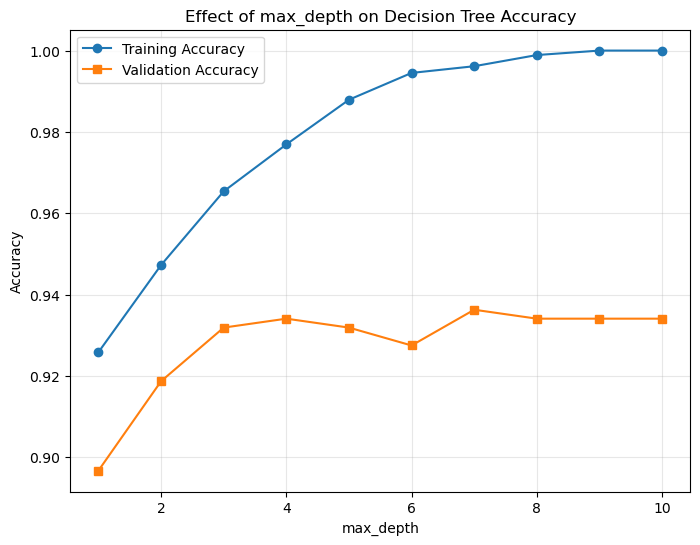

In [12]:
# Using validation_curve to measure training vs validation accuracy
# as max_depth increases from 1 to 10
depth_range = range(1, 11)
train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(random_state=42),
    X_train_scaled, y_train,
    param_name="max_depth",
    param_range=depth_range,
    cv=5,
    scoring="accuracy"
)

# Taking the average score across the 5 cross-validation folds
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

# Plotting both lines on the same graph
plt.figure(figsize=(8, 6))
plt.plot(depth_range, train_mean, marker='o', label="Training Accuracy")
plt.plot(depth_range, val_mean, marker='s', label="Validation Accuracy")
plt.title("Effect of max_depth on Decision Tree Accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

# Saving the plot as required
plt.savefig("hyperparameter_impact.png", dpi=100, bbox_inches='tight')
plt.show()

## Model Comparison Matrix

This grouped bar chart compares the three optimized models using Accuracy, F1-Score, and ROC-AUC. It gives a quick visual summary of which model performed best.

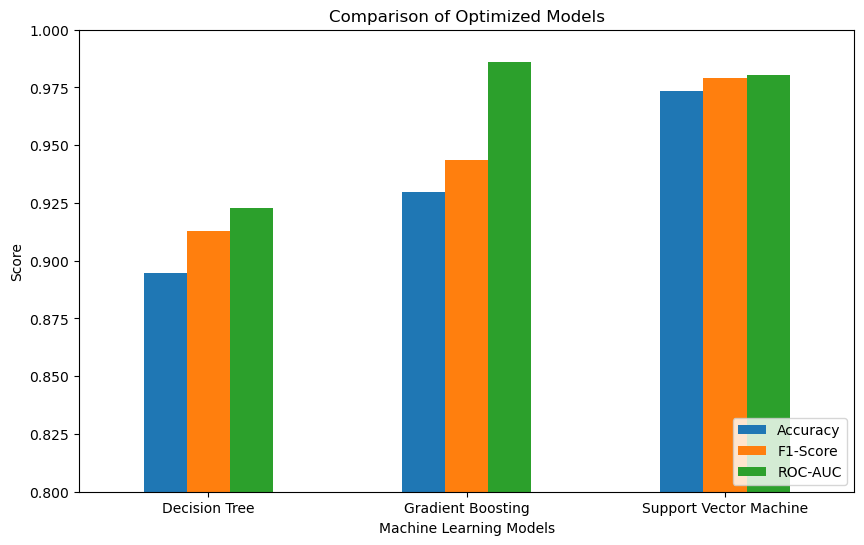

In [13]:
# Grouped bar chart comparing the three metrics across all models
results_df.set_index("Model")[["Accuracy", "F1-Score", "ROC-AUC"]].plot(
    kind="bar", figsize=(10, 6)
)
plt.title("Comparison of Optimized Models")
plt.xlabel("Machine Learning Models")
plt.ylabel("Score")

# Setting the y-axis from 0.8 to 1.0 so the differences are easier to see
plt.ylim(0.8, 1.0)
plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.savefig("model_comparison.png", dpi=100, bbox_inches='tight')
plt.show()

## Confusion Matrix Heatmap

The confusion matrix below is for the Gradient Boosting model, which is the boosting ensemble in this assignment. It shows how many cases were predicted correctly and incorrectly. The off-diagonal values are the errors: false positives and false negatives. In a cancer diagnosis problem, a false negative (a malignant tumor predicted as benign) is the most serious type of error.

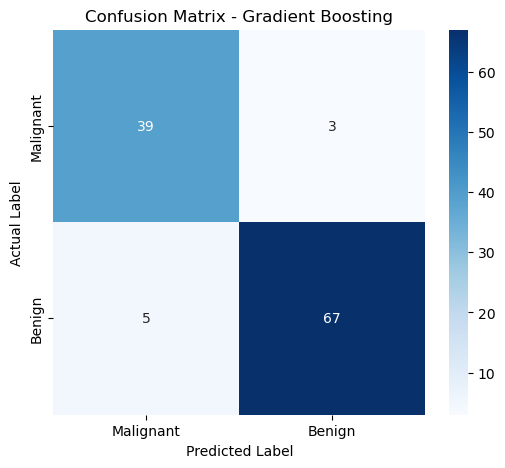

In [14]:
# Confusion matrix for the Gradient Boosting ensemble model
gb_model = best_models["Gradient Boosting"]
gb_pred = gb_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, gb_pred)

# Drawing the confusion matrix as a heatmap using seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)
plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.savefig("confusion_matrix.png", dpi=100, bbox_inches='tight')
plt.show()

## Conclusion

In this assignment I built a full machine learning pipeline to predict whether a breast tumor is malignant or benign. I selected the five features most correlated with the target, scaled them, and trained three models: a Decision Tree baseline, a Gradient Boosting ensemble, and an SVM with an RBF kernel. Each model was tuned using GridSearchCV.

After comparing the models using Accuracy, F1-Score, and ROC-AUC, the SVM gave the highest accuracy and F1-Score, while Gradient Boosting had the highest ROC-AUC. Both clearly outperformed the baseline Decision Tree, which shows the benefit of using more advanced models and hyperparameter tuning. The confusion matrix for the Gradient Boosting model showed only a small number of false negatives, which is important because missing a malignant case is the most costly error in medical diagnosis.